# ACIT4530 Assignment C — DBLP Data Exploration & Tensor Decomposition

Tasks covered end-to-end:
1. **Data exploration** (Q1–Q5)
2. **CP / PARAFAC tensor factorization**: rank=2 stability via FMS, R sweep,
   component interpretation, 2005 prediction by averaging the last three reconstructed years

See `THEORY.md` for the theory behind every function and parameter choice.
The SVD section in `THEORY.md` is background reading; it is not implemented in this notebook.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.metrics import roc_curve, roc_auc_score

import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor
from tlviz.factor_tools import factor_match_score

tl.set_backend("numpy")
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110


In [2]:
mat = loadmat("DBLP.mat")
X = mat["X"].astype(np.float64)          # (471 authors, 366 conferences, 14 years)
Y_raw = mat["Y"].astype(np.float64)      # (471, 366) ground truth for 2005

author_names = [str(mat["Author_Names"][i, 0][0]) for i in range(mat["Author_Names"].shape[0])]
conf_names   = [str(mat["Conf_Names"][j, 0][0])   for j in range(mat["Conf_Names"].shape[0])]

n_authors, n_confs, n_years = X.shape
years = list(range(1991, 1991 + n_years))   # 1991..2004
print(f"X shape: {X.shape}  (authors x conferences x years {years[0]}..{years[-1]})")
print(f"Y shape: {Y_raw.shape}  (ground truth for 2005)")
print(f"Number of authors:     {n_authors}")
print(f"Number of conferences: {n_confs}")


X shape: (471, 366, 14)  (authors x conferences x years 1991..2004)
Y shape: (471, 366)  (ground truth for 2005)
Number of authors:     471
Number of conferences: 366


## 1. Data exploration

Five questions from the assignment, answered on the **raw** `X` (before any log-transform).

### Q1. Top five authors by total publications

In [3]:
pubs_per_author = X.sum(axis=(1, 2))      # collapse conferences and years
top5_authors_idx = np.argsort(pubs_per_author)[::-1][:5]

top5_authors = pd.DataFrame({
    "author": [author_names[i] for i in top5_authors_idx],
    "publications": pubs_per_author[top5_authors_idx].astype(int),
})
top5_authors


,author,publications
0,Sudhakar M Reddy,212
1,Irith Pomeranz,199
2,Alberto L Sangiovanni Vincentelli,182
3,Edwin R Hancock,178
4,Thomas S Huang,176


### Q2. Top ten conferences by total publications

In [4]:
pubs_per_conf = X.sum(axis=(0, 2))
top10_confs_idx = np.argsort(pubs_per_conf)[::-1][:10]

top10_confs = pd.DataFrame({
    "conference": [conf_names[j] for j in top10_confs_idx],
    "publications": pubs_per_conf[top10_confs_idx].astype(int),
})
top10_confs


,conference,publications
0,CONF/DAC,1096
1,CONF/ICCAD,853
2,CONF/ICIP,724
3,CONF/IPPS,639
4,CONF/DATE,612
5,CONF/VLDB,554
6,CONF/SIGMOD,524
7,CONF/ICDE,457
8,CONF/ICCD,456
9,CONF/ITC,434


### Q3. Top five (author, conference) pairs by total publications across all years

In [5]:
pair_totals = X.sum(axis=2)                       # (471, 366) collapsed years
flat = pair_totals.flatten()
top5_pair_flat = np.argsort(flat)[::-1][:5]
top5_pairs = []
for idx in top5_pair_flat:
    i, j = np.unravel_index(idx, pair_totals.shape)
    top5_pairs.append({
        "author":      author_names[i],
        "conference":  conf_names[j],
        "publications": int(pair_totals[i, j]),
    })
top5_pairs_df = pd.DataFrame(top5_pairs)
top5_pairs_df


,author,conference,publications
0,Toshio Fukuda,CONF/ICRA,101
1,Ron Kikinis,CONF/MICCAI,61
2,Aggelos K Katsaggelos,CONF/ICIP,60
3,Bernd Girod,CONF/ICIP,56
4,Micha Sharir,CONF/COMPGEOM,54


### Q4. Conferences that did not happen every year

A conference is "missing in a year" if no author published there that year. We list every
conference that has at least one missing year, then summarize.

In [6]:
conf_year_activity = X.sum(axis=0)                # (366 confs, 14 years), >0 means active that year
years_active_per_conf = (conf_year_activity > 0).sum(axis=1)

missing_years_per_conf = n_years - years_active_per_conf
n_confs_with_gaps = int((missing_years_per_conf > 0).sum())
print(f"Conferences with at least one missing year: {n_confs_with_gaps} / {n_confs}")
print(f"Mean missing years (over confs with gaps):  {missing_years_per_conf[missing_years_per_conf>0].mean():.2f}")
print(f"Conferences that NEVER appear in 1991..2004: {(years_active_per_conf == 0).sum()}")

gaps_df = pd.DataFrame({
    "conference": conf_names,
    "years_active": years_active_per_conf,
    "missing_years": missing_years_per_conf,
}).sort_values("missing_years", ascending=False)
print("\nTop 10 most-intermittent conferences:")
gaps_df.head(10)


Conferences with at least one missing year: 320 / 366
Mean missing years (over confs with gaps):  6.73
Conferences that NEVER appear in 1991..2004: 1

Top 10 most-intermittent conferences:


,conference,years_active,missing_years
50,CONF/CLEF,0,14
316,CONF/SMC,1,13
52,CONF/CMG,1,13
199,CONF/IJCNN,1,13
113,CONF/EWSPT,1,13
100,CONF/EH,1,13
41,CONF/CBMS,2,12
150,CONF/ICALT,2,12
13,CONF/AINA,2,12
208,CONF/ISBI,2,12


### Q5. Percentage of zeros vs non-zeros

In [7]:
total_entries = X.size
nnz = int(np.count_nonzero(X))
zeros = total_entries - nnz
print(f"Total entries: {total_entries:,}")
print(f"Non-zero:      {nnz:,}  ({100*nnz/total_entries:.3f}%)")
print(f"Zero:          {zeros:,}  ({100*zeros/total_entries:.3f}%)")
print(f"Sparsity:      {100*zeros/total_entries:.2f}% zero  -> very sparse")


Total entries: 2,413,404
Non-zero:      21,928  (0.909%)
Zero:          2,391,476  (99.091%)
Sparsity:      99.09% zero  -> very sparse


## 2. Log-transform and binarize Y

`X_ijk = log(X_ijk) + 1` for non-zero entries, zeros stay zero. `Y` is binarized
(any publication in 2005 → 1, else 0) because the task is link prediction.

In [8]:
X_log = np.zeros_like(X, dtype=np.float64)
mask = X > 0
X_log[mask] = np.log(X[mask]) + 1.0

Y = (Y_raw > 0).astype(np.float64)
print(f"X_log range: [{X_log.min():.3f}, {X_log.max():.3f}]")
print(f"Y is binary: unique values = {np.unique(Y)}")
print(f"Y positives: {int(Y.sum())} / {Y.size}  ({100*Y.mean():.3f}% positive class)")


X_log range: [0.000, 3.833]
Y is binary: unique values = [0. 1.]
Y positives: 2083 / 172386  (1.208% positive class)


## 3. Tensor factorization — CP / PARAFAC

CP factors the 3-way tensor into a sum of `R` rank-one components.
We work on the log-transformed tensor `X_log`.

### 3.1 Rank=2 stability — 15 random initializations + FMS

In [9]:
def fit_cp(tensor, rank, seed, n_iter_max=300, tol=1e-6):
    """Run one CP fit and return (cp_tensor, fit, n_iters, time_s, final_err).

    n_iter_max=300, tol=1e-6 are tight enough for stable factors on this 471x366x14 tensor
    while keeping the full R-sweep tractable.
    """
    t0 = time.time()
    cp_tensor, errors = parafac(
        tensor,
        rank=rank,
        init="random",
        n_iter_max=n_iter_max,
        tol=tol,
        random_state=seed,
        return_errors=True,
        normalize_factors=True,
    )
    elapsed = time.time() - t0
    rec = cp_to_tensor(cp_tensor)
    fit = 1.0 - np.linalg.norm(tensor - rec) / np.linalg.norm(tensor)
    return cp_tensor, fit, len(errors), elapsed, errors[-1]


N_INITS = 15
RANK = 2
rank2_runs = []
for seed in range(N_INITS):
    cp_tensor, fit, n_iters, elapsed, final_err = fit_cp(X_log, RANK, seed)
    rank2_runs.append({
        "seed": seed, "fit": fit, "iters": n_iters,
        "time_s": elapsed, "final_err": final_err, "cp": cp_tensor,
    })
    print(f"seed={seed:2d}  fit={fit:.4f}  iters={n_iters:4d}  time={elapsed:5.2f}s  final_err={final_err:.4e}")

rank2_df = pd.DataFrame([{k: r[k] for k in ["seed", "fit", "iters", "time_s", "final_err"]} for r in rank2_runs])
print("\nFit / iteration / time summary for R=2:")
print(rank2_df.describe().round(4))


seed= 0  fit=0.0429  iters=  20  time= 1.45s  final_err=9.5708e-01
seed= 1  fit=0.0429  iters=  57  time= 3.11s  final_err=9.5710e-01
seed= 2  fit=0.0429  iters=  28  time= 1.50s  final_err=9.5708e-01
seed= 3  fit=0.0429  iters=  59  time= 3.10s  final_err=9.5708e-01
seed= 4  fit=0.0429  iters=  25  time= 1.26s  final_err=9.5708e-01
seed= 5  fit=0.0429  iters=  56  time= 3.03s  final_err=9.5708e-01
seed= 6  fit=0.0429  iters=  13  time= 0.47s  final_err=9.5707e-01
seed= 7  fit=0.0429  iters=  13  time= 0.50s  final_err=9.5708e-01
seed= 8  fit=0.0429  iters=  40  time= 1.55s  final_err=9.5710e-01
seed= 9  fit=0.0429  iters=  13  time= 0.60s  final_err=9.5707e-01
seed=10  fit=0.0429  iters=  15  time= 0.58s  final_err=9.5709e-01
seed=11  fit=0.0429  iters=  18  time= 0.74s  final_err=9.5708e-01
seed=12  fit=0.0429  iters=  53  time= 2.17s  final_err=9.5710e-01
seed=13  fit=0.0429  iters=  71  time= 3.24s  final_err=9.5708e-01
seed=14  fit=0.0429  iters=  56  time= 2.07s  final_err=9.5708

**FMS across runs (R=2).** A 15×15 matrix; values near 1 mean different inits found the same
decomposition (stable rank), values near 0 mean the algorithm landed in different local optima.

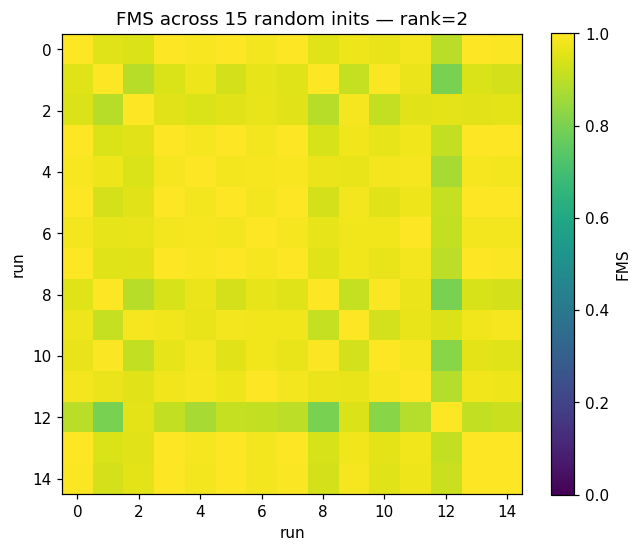

FMS pairwise — mean: 0.959, min: 0.797, max: 1.000
If most entries are >0.9, R=2 is a stable decomposition; lower values suggest sensitivity to init.


In [10]:
N = len(rank2_runs)
fms_mat = np.eye(N)
for i in range(N):
    for j in range(i + 1, N):
        fms = factor_match_score(rank2_runs[i]["cp"], rank2_runs[j]["cp"])
        fms_mat[i, j] = fms_mat[j, i] = fms

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(fms_mat, cmap="viridis", vmin=0, vmax=1)
ax.set_title("FMS across 15 random inits — rank=2")
ax.set_xlabel("run"); ax.set_ylabel("run")
plt.colorbar(im, ax=ax, label="FMS")
plt.tight_layout(); plt.show()

upper = fms_mat[np.triu_indices(N, k=1)]
print(f"FMS pairwise — mean: {upper.mean():.3f}, min: {upper.min():.3f}, max: {upper.max():.3f}")
print("If most entries are >0.9, R=2 is a stable decomposition; lower values suggest sensitivity to init.")


### 3.2 Sweep over R = {1, 4, 6, 8, 10, 12, 15, 20, 25, 50}

For each R we run **4 random inits**, keep the run with the lowest final error as the
representative, and report fit, mean FMS, mean iterations, mean time. (4 inits give 6 pairwise
FMS values per R — enough to estimate stability while keeping wall time tractable.)

The sweep is split across two cells: a low-R block first (R ≤ 15) so its results print
immediately, then a heavy-R block (R ∈ {20, 25, 50}). Larger R uses progressively looser
tolerance / fewer iterations because CP at those ranks is overparameterised on this tensor
anyway — past R≈10 the components start to duplicate and tightening tol gives diminishing
returns at high compute cost.

In [11]:
R_VALUES = [1, 4, 6, 8, 10, 12, 15, 20, 25, 50]
N_INITS_SWEEP = 4
sweep_results = {}     # R -> list of run dicts

def run_sweep_for(R, n_inits=N_INITS_SWEEP, n_iter_max=300, tol=1e-6):
    runs = []
    for seed in range(n_inits):
        cp_t, fit, n_iters, elapsed, final_err = fit_cp(
            X_log, R, seed, n_iter_max=n_iter_max, tol=tol
        )
        runs.append({"seed": seed, "cp": cp_t, "fit": fit, "iters": n_iters,
                     "time_s": elapsed, "final_err": final_err})
    fits = [r["fit"] for r in runs]
    print(f"R={R:2d} | fit mean={np.mean(fits):.4f}  best={max(fits):.4f}  "
          f"iters mean={np.mean([r['iters'] for r in runs]):.0f}  "
          f"time mean={np.mean([r['time_s'] for r in runs]):.2f}s",
          flush=True)
    return runs

# Low-R block: cheap and fast — gives the elbow region
for R in [1, 4, 6, 8, 10, 12, 15]:
    sweep_results[R] = run_sweep_for(R)
print("\nLow-R block done.")


R= 1 | fit mean=0.0289  best=0.0289  iters mean=9  time mean=0.39s
R= 4 | fit mean=0.0662  best=0.0662  iters mean=95  time mean=4.96s
R= 6 | fit mean=0.0847  best=0.0848  iters mean=94  time mean=4.90s
R= 8 | fit mean=0.0990  best=0.0993  iters mean=132  time mean=9.09s
R=10 | fit mean=0.1109  best=0.1109  iters mean=114  time mean=8.44s
R=12 | fit mean=0.1198  best=0.1199  iters mean=185  time mean=14.28s
R=15 | fit mean=0.1331  best=0.1335  iters mean=187  time mean=15.76s

Low-R block done.


Heavy-R block. Tolerance is relaxed at R=25, R=50 — see the markdown above for why.

In [12]:
sweep_results[20] = run_sweep_for(20, n_iter_max=200, tol=1e-5)
sweep_results[25] = run_sweep_for(25, n_iter_max=150, tol=1e-5)
sweep_results[50] = run_sweep_for(50, n_iter_max=100, tol=1e-4)
print("\nSweep complete. R values fit:", sorted(sweep_results.keys()))


R=20 | fit mean=0.1507  best=0.1508  iters mean=116  time mean=12.46s
R=25 | fit mean=0.1656  best=0.1657  iters mean=104  time mean=11.26s
R=50 | fit mean=0.2187  best=0.2206  iters mean=65  time mean=9.73s

Sweep complete. R values fit: [1, 4, 6, 8, 10, 12, 15, 20, 25, 50]


    best_fit  mean_fit  mean_FMS  mean_iters  mean_time_s
R                                                        
1     0.0289    0.0289    1.0000        8.75       0.3857
4     0.0662    0.0662    0.6497       94.75       4.9557
6     0.0848    0.0847    0.7737       94.50       4.9032
8     0.0993    0.0990    0.7696      132.25       9.0945
10    0.1109    0.1109    0.9573      113.50       8.4432
12    0.1199    0.1198    0.8851      185.00      14.2811
15    0.1335    0.1331    0.8289      186.75      15.7603
20    0.1508    0.1507    0.7493      115.75      12.4620
25    0.1657    0.1656    0.7339      104.00      11.2572
50    0.2206    0.2187    0.4392       64.75       9.7335


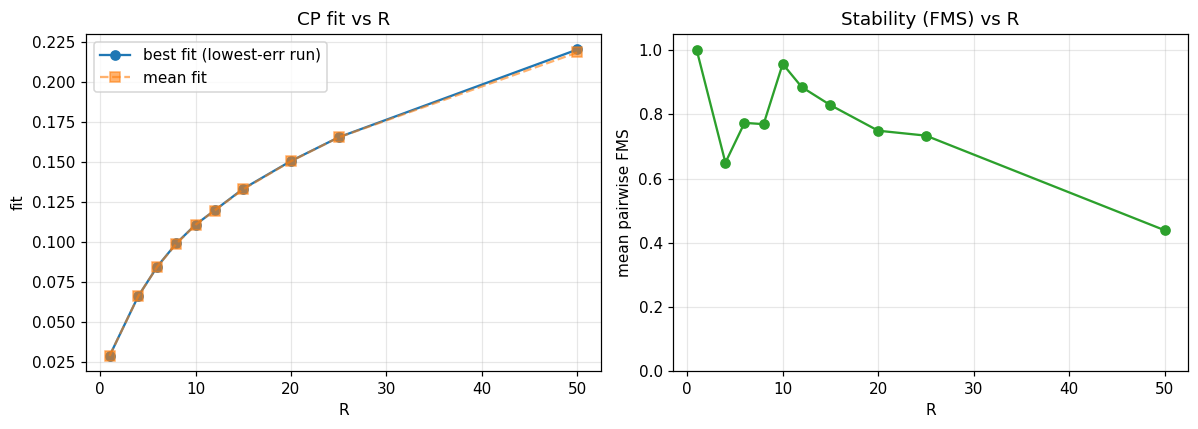


Observation: fit increases with R but stability (FMS) typically drops past a few components.
Look for an elbow in fit AND a still-respectable FMS to pick R.


In [13]:
# Mean pairwise FMS within each R (stability indicator)
def mean_fms(runs):
    n = len(runs)
    vals = []
    for i in range(n):
        for j in range(i + 1, n):
            vals.append(factor_match_score(runs[i]["cp"], runs[j]["cp"]))
    return float(np.mean(vals)) if vals else 1.0

summary_rows = []
for R, runs in sweep_results.items():
    best = min(runs, key=lambda r: r["final_err"])
    summary_rows.append({
        "R": R,
        "best_fit": best["fit"],
        "mean_fit": float(np.mean([r["fit"] for r in runs])),
        "mean_FMS": mean_fms(runs),
        "mean_iters": float(np.mean([r["iters"] for r in runs])),
        "mean_time_s": float(np.mean([r["time_s"] for r in runs])),
    })
sweep_summary = pd.DataFrame(summary_rows).set_index("R")
print(sweep_summary.round(4))

# Plot fit vs R and mean FMS vs R
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sweep_summary.index, sweep_summary["best_fit"], "o-", label="best fit (lowest-err run)")
axes[0].plot(sweep_summary.index, sweep_summary["mean_fit"], "s--", label="mean fit", alpha=0.6)
axes[0].set_xlabel("R"); axes[0].set_ylabel("fit"); axes[0].set_title("CP fit vs R")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_summary.index, sweep_summary["mean_FMS"], "o-", color="C2")
axes[1].set_xlabel("R"); axes[1].set_ylabel("mean pairwise FMS"); axes[1].set_title("Stability (FMS) vs R")
axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print("\nObservation: fit increases with R but stability (FMS) typically drops past a few components.")
print("Look for an elbow in fit AND a still-respectable FMS to pick R.")


### 3.3 Interpret a component at the chosen rank

We pick a moderate rank (R=6 — usually enough to capture structure while keeping FMS high)
and look at one component: its author loadings, its conference loadings, and its temporal
profile. Then we check it against the raw data.

In [14]:
R_PICK = 6
best_run = min(sweep_results[R_PICK], key=lambda r: r["final_err"])
weights, factors = best_run["cp"]
A, B, C = factors                     # author, conference, year factor matrices
print(f"Component weights at R={R_PICK}:", np.round(weights, 3))
print("Picking the component with the largest weight for inspection.")

comp_idx = int(np.argmax(weights))
print(f"\n>> Inspecting component {comp_idx} (largest weight = {weights[comp_idx]:.3f})")

def top_loadings(vec, names, k=10, sign="abs"):
    if sign == "abs":
        order = np.argsort(np.abs(vec))[::-1][:k]
    else:
        order = np.argsort(vec)[::-1][:k]
    return [(names[i], float(vec[i])) for i in order]

print("\nTop-10 authors:")
for n, v in top_loadings(A[:, comp_idx], author_names, 10):
    print(f"  {v:+.4f}  {n}")
print("\nTop-10 conferences:")
for n, v in top_loadings(B[:, comp_idx], conf_names, 10):
    print(f"  {v:+.4f}  {n}")


Component weights at R=6: [27.37  44.883 33.584 32.443 32.214 32.818]
Picking the component with the largest weight for inspection.

>> Inspecting component 1 (largest weight = 44.883)

Top-10 authors:
  +0.2440  Alberto L Sangiovanni Vincentelli
  +0.2182  Robert K Brayton
  +0.2066  Massoud Pedram
  +0.1975  Sudhakar M Reddy
  +0.1970  Irith Pomeranz
  +0.1870  Miodrag Potkonjak
  +0.1853  Jason Cong
  +0.1827  Andrew B Kahng
  +0.1819  D F Wong
  +0.1668  Kwang Ting Cheng

Top-10 conferences:
  +0.6719  CONF/DAC
  +0.5697  CONF/ICCAD
  +0.2138  CONF/ICCD
  +0.1441  CONF/DATE
  -0.1417  CONF/IPPS
  +0.1222  CONF/ISLPED
  +0.1219  CONF/ASPDAC
  +0.1203  CONF/ISPD
  +0.1134  CONF/ISCAS
  +0.1111  CONF/VLSID


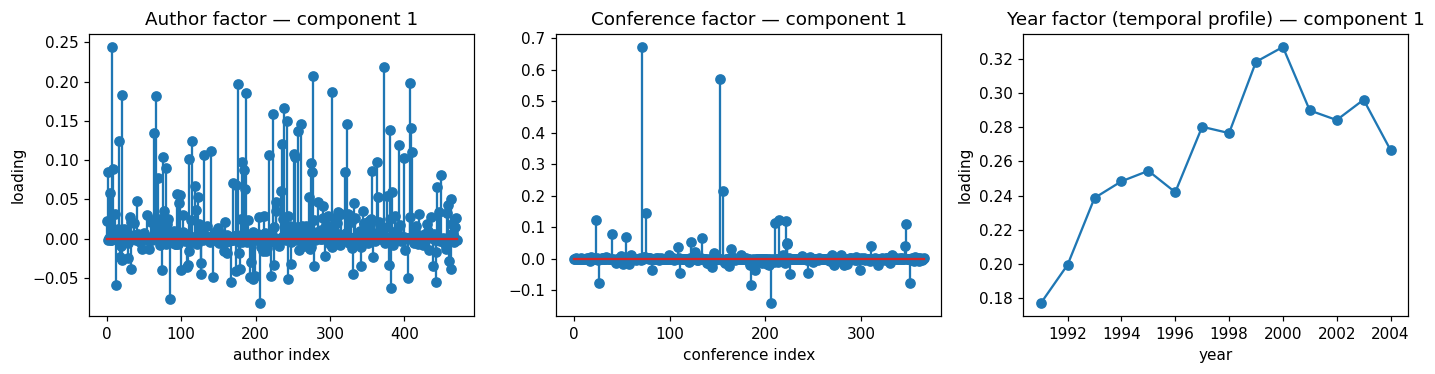

In [15]:
# Plot the component's three factor vectors
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].stem(A[:, comp_idx])
axes[0].set_title(f"Author factor — component {comp_idx}")
axes[0].set_xlabel("author index"); axes[0].set_ylabel("loading")

axes[1].stem(B[:, comp_idx])
axes[1].set_title(f"Conference factor — component {comp_idx}")
axes[1].set_xlabel("conference index")

axes[2].plot(years, C[:, comp_idx], "o-")
axes[2].set_title(f"Year factor (temporal profile) — component {comp_idx}")
axes[2].set_xlabel("year"); axes[2].set_ylabel("loading")
plt.tight_layout(); plt.show()


In [16]:
# Sanity check against the raw (unprocessed) data
top_authors_for_comp = np.argsort(np.abs(A[:, comp_idx]))[::-1][:5]
top_confs_for_comp   = np.argsort(np.abs(B[:, comp_idx]))[::-1][:5]
print("Sanity check: total RAW publications, summed over the top-5 authors and top-5 conferences")
print("of this component, year by year. Compare against the year-factor plot above.\n")
sub = X[np.ix_(top_authors_for_comp, top_confs_for_comp, np.arange(n_years))]   # (5,5,14)
yearly_sum = sub.sum(axis=(0, 1))
for y, v in zip(years, yearly_sum):
    print(f"  {y}: {int(v)} pubs")


Sanity check: total RAW publications, summed over the top-5 authors and top-5 conferences
of this component, year by year. Compare against the year-factor plot above.

  1991: 36 pubs
  1992: 35 pubs
  1993: 47 pubs
  1994: 42 pubs
  1995: 26 pubs
  1996: 33 pubs
  1997: 34 pubs
  1998: 23 pubs
  1999: 31 pubs
  2000: 33 pubs
  2001: 33 pubs
  2002: 32 pubs
  2003: 38 pubs
  2004: 25 pubs


### 3.4 Predict 2005 from CP — average the last 3 reconstructed years

For every R, take the run with the lowest final error, reconstruct the full tensor, then
score `X_hat[:, :, -3:].mean(axis=2)` against the binarized `Y`.

       AUC
R         
1   0.6212
4   0.8186
6   0.8490
8   0.8736
10  0.8763
12  0.8884
15  0.8860
20  0.8934
25  0.9001
50  0.8994

Best CP rank for 2005 prediction: R = 25, AUC = 0.9001


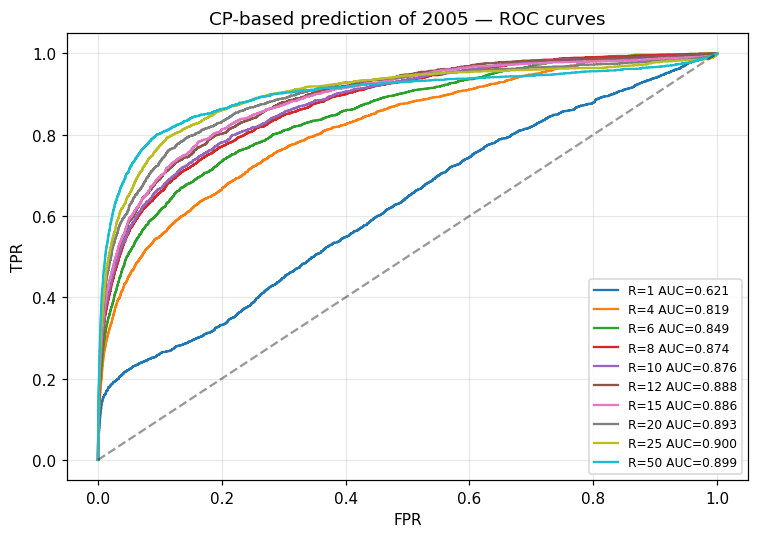

In [17]:
def safe_score(X_hat, Y, last_n=3):
    """Average the last `last_n` reconstructed time-points and align with Y by dropping
    rows/cols with non-finite predictions. Returns (y_true, y_score) ready for sklearn."""
    score = X_hat[:, :, -last_n:].mean(axis=2)
    s = score.flatten()
    y = Y.flatten()
    finite = np.isfinite(s)
    if not finite.all():
        n_bad = (~finite).sum()
        print(f"  ! dropped {n_bad} non-finite entries from scores ({100*n_bad/s.size:.3f}%)")
    return y[finite], s[finite]


aucs_cp = {}
for R, runs in sweep_results.items():
    best = min(runs, key=lambda r: r["final_err"])
    X_hat = cp_to_tensor(best["cp"])
    y_t, s_t = safe_score(X_hat, Y)
    aucs_cp[R] = roc_auc_score(y_t, s_t)

cp_auc_df = pd.DataFrame({"R": list(aucs_cp.keys()), "AUC": list(aucs_cp.values())}).set_index("R")
print(cp_auc_df.round(4))

best_R = max(aucs_cp, key=aucs_cp.get)
print(f"\nBest CP rank for 2005 prediction: R = {best_R}, AUC = {aucs_cp[best_R]:.4f}")

# Compare ROC curves at every R
fig, ax = plt.subplots(figsize=(7, 5))
for R, runs in sweep_results.items():
    best = min(runs, key=lambda r: r["final_err"])
    X_hat = cp_to_tensor(best["cp"])
    y_t, s_t = safe_score(X_hat, Y)
    fpr, tpr, _ = roc_curve(y_t, s_t)
    ax.plot(fpr, tpr, label=f"R={R} AUC={aucs_cp[R]:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("CP-based prediction of 2005 — ROC curves")
ax.legend(loc="lower right", fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Wrap-up

- The 15-init experiment at R=2 measures whether the decomposition is *stable* — high pairwise
  FMS means different random starts converge to the same components.
- The R sweep shows the classic trade-off: fit climbs with R, stability drops past the elbow.
  The right R balances both.
- Interpretation at R=6 turns each component into a coherent **theme** (a cluster of authors
  publishing at a cluster of conferences with a particular temporal pattern).
- Averaging the last three reconstructed time-points and scoring against `Y` gives a denoised
  link-prediction signal for 2005.

See `THEORY.md` for the full theoretical background, including the SVD theory that
contextualizes why CP is the more natural tool for this 3-way tensor.